In [1]:
import sys
import os
import matplotlib.pyplot as plt
# Add the project root to the Python path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from crater_analysis.io import read_crater_locations, read_dem
from crater_analysis.analysis import filter_craters, get_crater_profile, get_dem_snippet
from crater_analysis.plotting import plot_dem, plot_crater_locations
from crater_analysis.core import Crater

In [2]:
dem, metadata = read_dem('../data/dems/LDEM_60S_120M.JP2')

Successfully read DEM from ../data/dems/LDEM_60S_120M.JP2


In [ ]:
lat = 'LAT_CIRC_IMG'
lon = 'LON_CIRC_IMG'
diam = 'DIAM_CIRC_IMG'
# depth = 'DEPTH_RIM_FLOOR_IMG'  # Uncomment if catalog has depth column
#lat = 'lat'
#lon = 'lon'
#diam = 'diameter_m'
#depth = 'depth_m'

craters = read_crater_locations('../data/catalogs/lunar_crater_database_robbins_2018.csv')
craters = filter_craters(craters, pole='south', lat_threshold=60, circ_threshold=None, diam_min=2.5, diam_max=15, lat_col=lat, diam_col=diam)

#craters = read_crater_locations('../data/catalogs/moon_data.csv')
#craters = filter_craters(craters, pole='south', lat_threshold=60, circ_threshold=0.85, diam_min=2500, diam_max=None, lat_col=lat, diam_col=diam)

craters.head()

Successfully read 1296796 crater locations from ../data/catalogs/lunar_crater_database_robbins_2018.csv
Filtered to 29480 craters matching criteria.


,CRATER_ID,LAT_CIRC_IMG,LON_CIRC_IMG,LAT_ELLI_IMG,LON_ELLI_IMG,DIAM_CIRC_IMG,DIAM_CIRC_SD_IMG,DIAM_ELLI_MAJOR_IMG,DIAM_ELLI_MINOR_IMG,DIAM_ELLI_ECCEN_IMG,...,DIAM_ELLI_ANGLE_IMG,LAT_ELLI_SD_IMG,LON_ELLI_SD_IMG,DIAM_ELLI_MAJOR_SD_IMG,DIAM_ELLI_MINOR_SD_IMG,DIAM_ELLI_ANGLE_SD_IMG,DIAM_ELLI_ECCEN_SD_IMG,DIAM_ELLI_ELLIP_SD_IMG,ARC_IMG,PTS_RIM_IMG
391953,03-1-160614,-60.0012,198.703,-60.0007,198.702,5.45762,0.071329,5.49775,5.36149,0.221254,...,33.3635,0.000594,0.001184,0.031567,0.056422,12.22580,0.051530,0.012293,0.765616,29
392407,03-1-161185,-60.0100,234.499,-60.0077,234.489,3.83154,0.167495,4.59637,3.44654,0.661619,...,141.0780,0.000534,0.002294,0.077754,0.029273,2.07737,0.016086,0.025244,0.747188,22
392746,03-1-161605,-60.0286,265.950,-60.0237,265.954,4.70459,0.381053,5.93756,3.76418,0.773366,...,75.1746,0.001530,0.001957,0.126921,0.072097,1.61675,0.014916,0.045274,0.889694,35
392752,03-1-161611,-60.0133,264.666,-60.0123,264.661,4.24904,0.366566,5.38563,3.00806,0.829482,...,94.0451,0.000865,0.001238,0.060612,0.047158,1.06202,0.007258,0.034552,1.000000,33
464291,05-1-001929,-60.0529,291.342,-60.0530,291.346,7.91841,0.197877,8.39349,7.25355,0.503170,...,106.6300,0.000341,0.000918,0.024794,0.029894,1.33555,0.007526,0.005867,0.800293,90


In [5]:
### Initialise Craters ###
# Create an empty list to hold the Crater objects
crater_objects = []

# Loop through the first few rows of the DataFrame for demonstration
# To process all craters, change `craters.head(1).iterrows()` to `craters.iterrows()`
for index, row in craters.iterrows():
    # Extract crater properties from the row
    crater_id = None #row['CRATER_ID']
    crater_lon = row[lon]
    crater_lat = row[lat]
    crater_diam_km = row[diam]  # Diameter already in km for Robbins catalog
    
    # Get the DEM snippet for this crater
    dem_snippet, snippet_meta, center_coords = get_dem_snippet(
        dem,
        metadata,
        crater_lon,
        crater_lat,
        crater_diam_km,
        padding_factor=1.5
    )
    
    # Create the Crater object
    crater_obj = Crater(
        crater_id=crater_id,
        dem_snippet=dem_snippet,
        metadata=snippet_meta,
        center_coords=center_coords,
        global_coords={'lon': crater_lon, 'lat': crater_lat},
    )
    
    crater_obj.add_property('diameter_km', crater_diam_km)
    # Uncomment below if catalog has depth column:
    # crater_depth_m = row[depth] * 1000 if depth in row else None  # Convert km to m if needed
    # crater_obj.add_property('depth_m', crater_depth_m)

    # Add the new object to our list
    crater_objects.append(crater_obj)

    if index % 100 == 0:
        print(f'Processed crater {index}')

# Print a summary to confirm it worked
print(f"Successfully initialized {len(crater_objects)} Crater objects.")
if crater_objects:
    print("First crater object in the list:")
    print(crater_objects[50])

    print(crater_objects[50].dem_data)

Processed crater 1176200
Processed crater 1176300
Processed crater 1176300
Processed crater 1176500
Processed crater 1176500
Processed crater 1176700
Processed crater 1176700
Processed crater 1177000
Processed crater 1177000
Processed crater 1177100
Processed crater 1177100
Processed crater 1177300
Processed crater 1177300
Processed crater 1177800
Processed crater 1177800
Processed crater 1177900
Processed crater 1177900
Processed crater 1179600
Processed crater 1179600
Processed crater 1181300
Processed crater 1181300
Processed crater 1181700
Processed crater 1181700
Processed crater 1182100
Processed crater 1182100
Processed crater 1182700
Processed crater 1182700
Processed crater 1182800
Processed crater 1182800
Processed crater 1183200
Processed crater 1183200
Processed crater 1183900
Processed crater 1183900
Processed crater 1184300
Processed crater 1184300
Processed crater 1184700
Processed crater 1184700
Processed crater 1185500
Processed crater 1185500
Processed crater 1185600


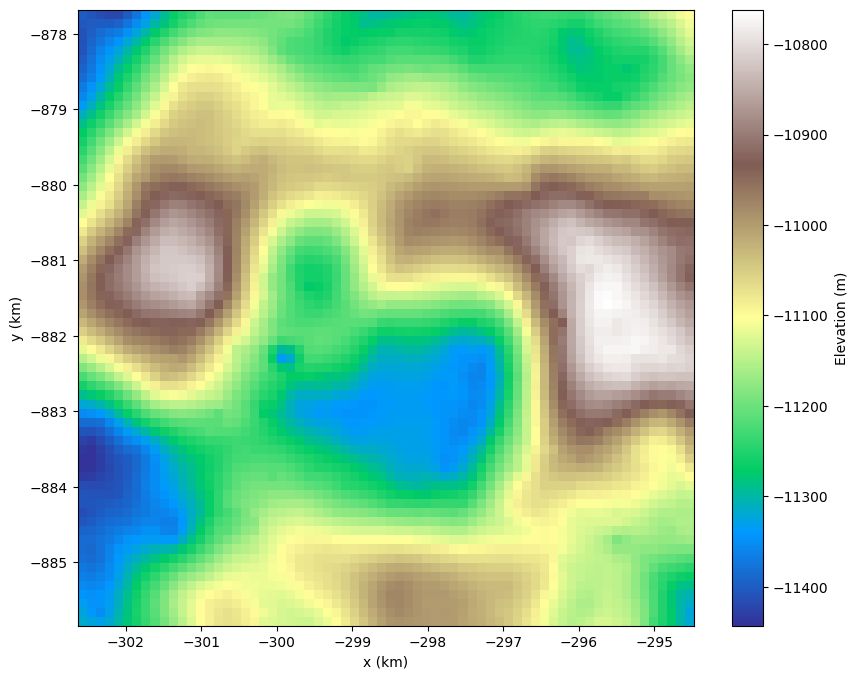

(<Figure size 1000x800 with 2 Axes>, <Axes: xlabel='x (km)', ylabel='y (km)'>)

In [6]:
plot_dem(crater_objects[0].dem_data, crater_objects[0].metadata)

## Extract a 2D Profile from a Crater

The `get_crater_profile` function uses Bresenham's line algorithm to sample actual pixel values along the profile, giving you the true DEM resolution without any interpolation.

Parameters:
- `dem_data`: The DEM array (can be the full DEM or a snippet)
- `metadata`: The corresponding metadata
- `crater_lon`, `crater_lat`: The crater's center coordinates
- `crater_diam_km`: The crater's diameter in kilometers
- `angle`: Angle of the profile in degrees (0=horizontal/E-W, 90=vertical/N-S)

DEM Snippet Stats:
  Min: -11443
  Max: -10762
  Mean: -11122.198529411764
  Nodata value: None

Profile Stats:
  Horizontal Profile - Min: -11297, Max: -10776, Range: 521
  Vertical Profile   - Min: -11337, Max: -10980, Range: 357

Horizontal profile: 68 pixels, slope=110.53 m/km
Vertical profile: 67 pixels, slope=86.82 m/km

Profile Stats:
  Horizontal Profile - Min: -11297, Max: -10776, Range: 521
  Vertical Profile   - Min: -11337, Max: -10980, Range: 357

Horizontal profile: 68 pixels, slope=110.53 m/km
Vertical profile: 67 pixels, slope=86.82 m/km


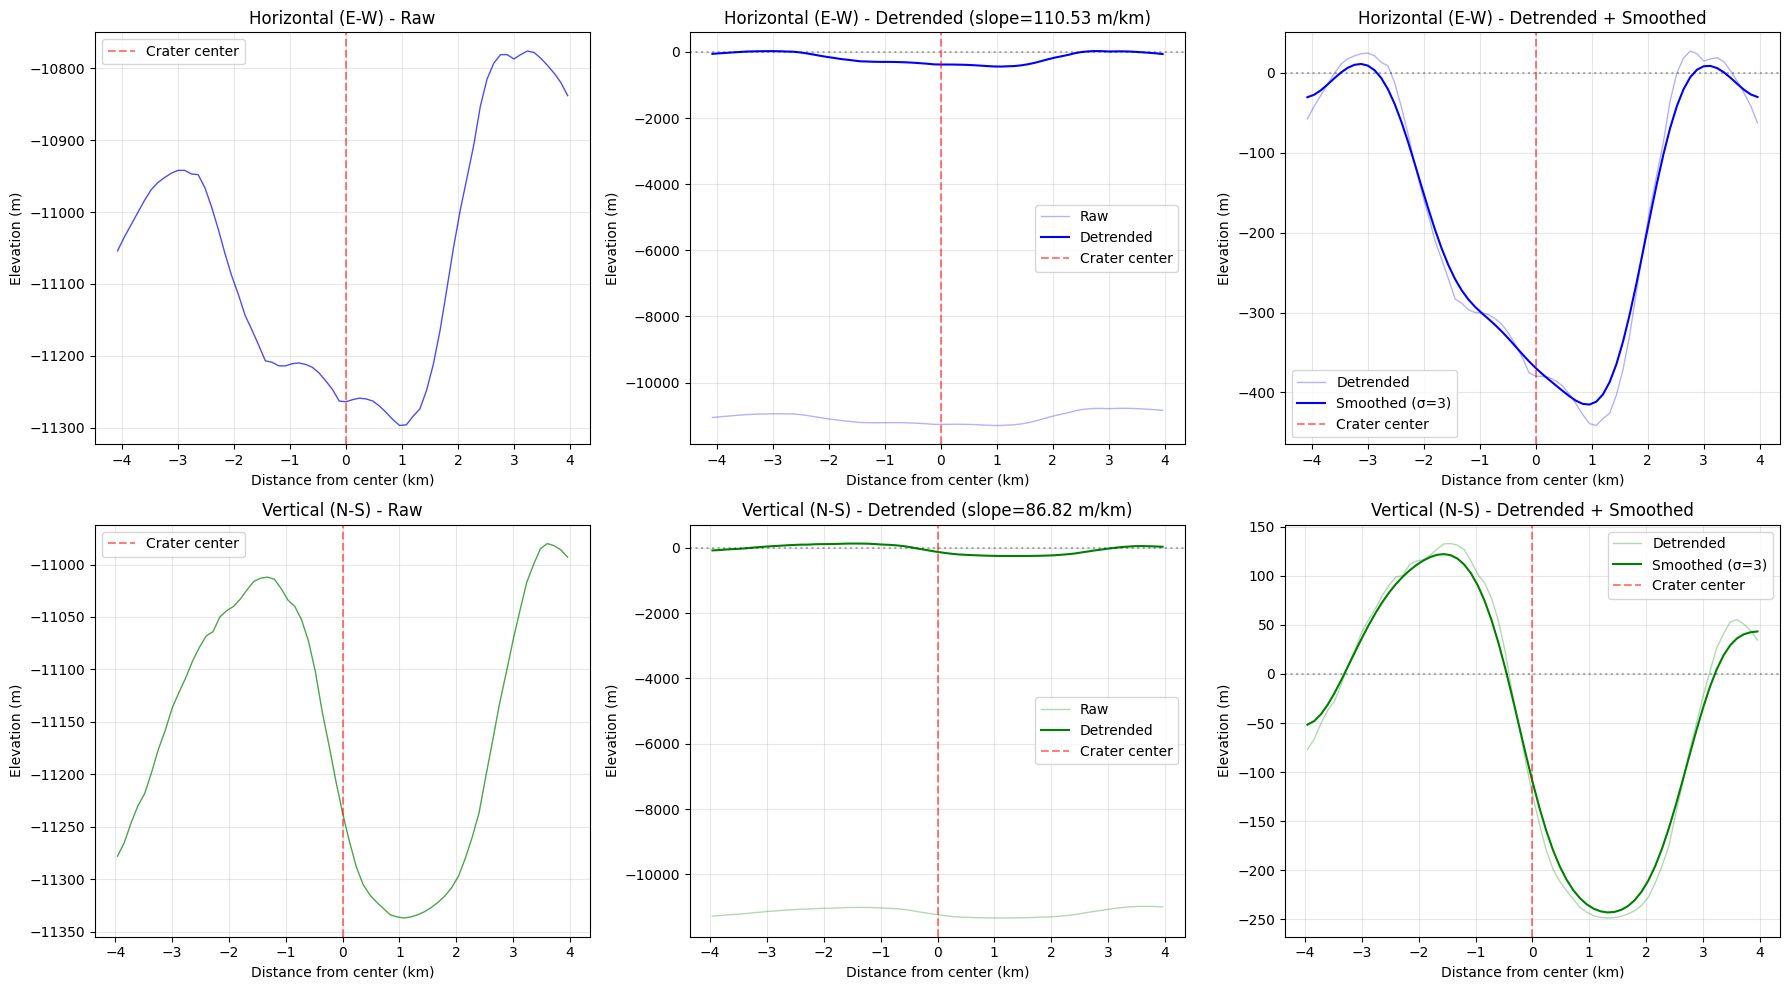

In [7]:
# Import the analysis functions
from crater_analysis.analysis import detrend_profile, smooth_profile, detrend_profile_robust
import numpy as np

# Extract profiles in both horizontal and vertical directions
crater = crater_objects[0]

# Check DEM stats
print(f"DEM Snippet Stats:")
print(f"  Min: {np.min(crater.dem_data)}")
print(f"  Max: {np.max(crater.dem_data)}")
print(f"  Mean: {np.mean(crater.dem_data)}")
print(f"  Nodata value: {crater.metadata.get('nodata')}")

# Horizontal profile (E-W, angle=0)
distance_h, elevation_h, pixel_coords_h = get_crater_profile(
    crater.dem_data,
    crater.metadata,
    crater.global_coords['lon'],
    crater.global_coords['lat'],
    crater_diam_km=crater.get_property('diameter_km') * 1.5,
    angle=0  # 0 degrees = horizontal (E-W)
)

# Vertical profile (N-S, angle=90)
distance_v, elevation_v, pixel_coords_v = get_crater_profile(
    crater.dem_data,
    crater.metadata,
    crater.global_coords['lon'],
    crater.global_coords['lat'],
    crater_diam_km=crater.get_property('diameter_km') * 1.5,
    angle=90  # 90 degrees = vertical (N-S)
)

print(f"\nProfile Stats:")
print(f"  Horizontal Profile - Min: {np.min(elevation_h)}, Max: {np.max(elevation_h)}, Range: {np.ptp(elevation_h)}")
print(f"  Vertical Profile   - Min: {np.min(elevation_v)}, Max: {np.max(elevation_v)}, Range: {np.ptp(elevation_v)}")

# Detrend the profiles first to remove regional slope
# Using robust detrending to avoid fitting the crater shape itself
elevation_h_detrended, slope_h, intercept_h = detrend_profile_robust(distance_h, elevation_h, fraction=0.2)
elevation_v_detrended, slope_v, intercept_v = detrend_profile_robust(distance_v, elevation_v, fraction=0.2)

# Then apply Gaussian smoothing to remove small-scale noise
# sigma controls the amount of smoothing (larger = more smoothing)
sigma = 3  # Try values between 1-5 depending on noise level
elevation_h_smooth = smooth_profile(elevation_h_detrended, sigma=sigma)
elevation_v_smooth = smooth_profile(elevation_v_detrended, sigma=sigma)

print(f"\nHorizontal profile: {len(elevation_h)} pixels, slope={slope_h:.2f} m/km")
print(f"Vertical profile: {len(elevation_v)} pixels, slope={slope_v:.2f} m/km")

# Plot raw, detrended, and smoothed profiles
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Horizontal profile - Raw
axes[0, 0].plot(distance_h, elevation_h, '-', linewidth=1, color='blue', alpha=0.7)
axes[0, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[0, 0].set_xlabel('Distance from center (km)')
axes[0, 0].set_ylabel('Elevation (m)')
axes[0, 0].set_title(f'Horizontal (E-W) - Raw')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Horizontal profile - Detrended
axes[0, 1].plot(distance_h, elevation_h, '-', linewidth=1, color='blue', alpha=0.3, label='Raw')
axes[0, 1].plot(distance_h, elevation_h_detrended, '-', linewidth=1.5, color='blue', label=f'Detrended')
axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[0, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 1].set_xlabel('Distance from center (km)')
axes[0, 1].set_ylabel('Elevation (m)')
axes[0, 1].set_title(f'Horizontal (E-W) - Detrended (slope={slope_h:.2f} m/km)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Horizontal profile - Smoothed
axes[0, 2].plot(distance_h, elevation_h_detrended, '-', linewidth=1, color='blue', alpha=0.3, label='Detrended')
axes[0, 2].plot(distance_h, elevation_h_smooth, '-', linewidth=1.5, color='blue', label=f'Smoothed (σ={sigma})')
axes[0, 2].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[0, 2].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 2].set_xlabel('Distance from center (km)')
axes[0, 2].set_ylabel('Elevation (m)')
axes[0, 2].set_title(f'Horizontal (E-W) - Detrended + Smoothed')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Vertical profile - Raw
axes[1, 0].plot(distance_v, elevation_v, '-', linewidth=1, color='green', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[1, 0].set_xlabel('Distance from center (km)')
axes[1, 0].set_ylabel('Elevation (m)')
axes[1, 0].set_title(f'Vertical (N-S) - Raw')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Vertical profile - Detrended
axes[1, 1].plot(distance_v, elevation_v, '-', linewidth=1, color='green', alpha=0.3, label='Raw')
axes[1, 1].plot(distance_v, elevation_v_detrended, '-', linewidth=1.5, color='green', label=f'Detrended')
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[1, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 1].set_xlabel('Distance from center (km)')
axes[1, 1].set_ylabel('Elevation (m)')
axes[1, 1].set_title(f'Vertical (N-S) - Detrended (slope={slope_v:.2f} m/km)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Vertical profile - Smoothed
axes[1, 2].plot(distance_v, elevation_v_detrended, '-', linewidth=1, color='green', alpha=0.3, label='Detrended')
axes[1, 2].plot(distance_v, elevation_v_smooth, '-', linewidth=1.5, color='green', label=f'Smoothed (σ={sigma})')
axes[1, 2].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[1, 2].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 2].set_xlabel('Distance from center (km)')
axes[1, 2].set_ylabel('Elevation (m)')
axes[1, 2].set_title(f'Vertical (N-S) - Detrended + Smoothed')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Horizontal profile floor: distance=1.320 km, elevation=-386.85 m
Vertical profile floor: distance=0.360 km, elevation=-179.13 m


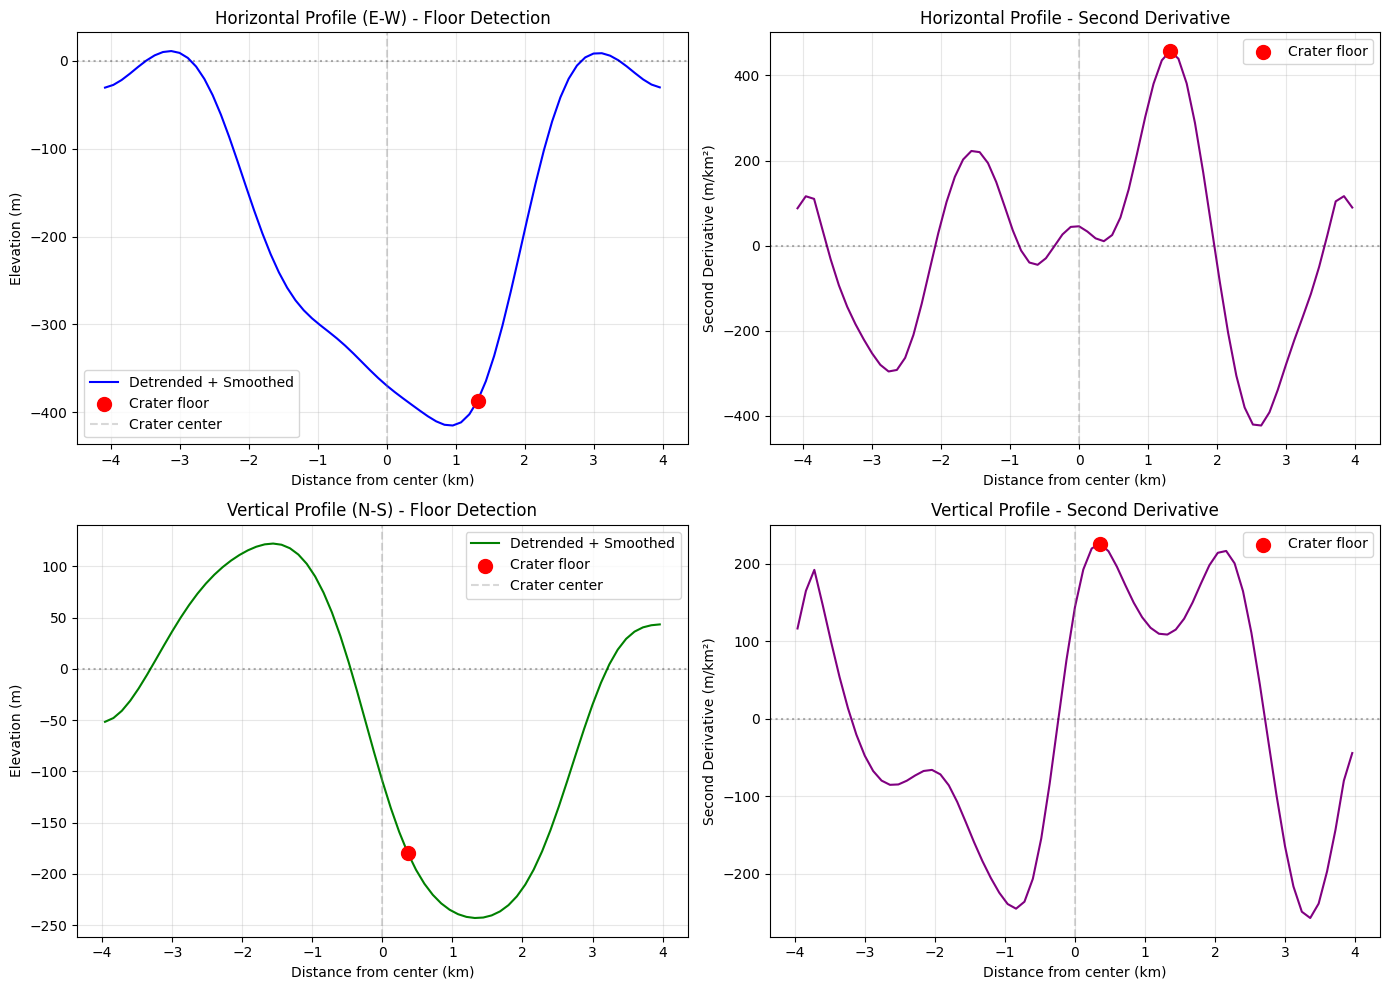

In [8]:
# Import the crater floor finding function
from crater_analysis.analysis import find_crater_floor, find_crater_floor_max_curv

# Find the deepest point in the horizontal profile (using smoothed data)
floor_idx_h, floor_dist_h, floor_elev_h, second_deriv_h = find_crater_floor_max_curv(distance_h, elevation_h_smooth)

# Find the deepest point in the vertical profile (using smoothed data)
floor_idx_v, floor_dist_v, floor_elev_v, second_deriv_v = find_crater_floor_max_curv(distance_v, elevation_v_smooth)

print(f"Horizontal profile floor: distance={floor_dist_h:.3f} km, elevation={floor_elev_h:.2f} m")
print(f"Vertical profile floor: distance={floor_dist_v:.3f} km, elevation={floor_elev_v:.2f} m")

# Plot the profiles with the identified floor locations and second derivatives
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Horizontal profile with floor marked
axes[0, 0].plot(distance_h, elevation_h_smooth, '-', linewidth=1.5, color='blue', label='Detrended + Smoothed')
axes[0, 0].scatter(floor_dist_h, floor_elev_h, color='red', s=100, zorder=5, label='Crater floor')
axes[0, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Crater center')
axes[0, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 0].set_xlabel('Distance from center (km)')
axes[0, 0].set_ylabel('Elevation (m)')
axes[0, 0].set_title('Horizontal Profile (E-W) - Floor Detection')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Horizontal second derivative
axes[0, 1].plot(distance_h, second_deriv_h, '-', linewidth=1.5, color='purple')
axes[0, 1].scatter(floor_dist_h, second_deriv_h[floor_idx_h], color='red', s=100, zorder=5, label='Crater floor')
axes[0, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.3)
axes[0, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 1].set_xlabel('Distance from center (km)')
axes[0, 1].set_ylabel('Second Derivative (m/km²)')
axes[0, 1].set_title('Horizontal Profile - Second Derivative')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Vertical profile with floor marked
axes[1, 0].plot(distance_v, elevation_v_smooth, '-', linewidth=1.5, color='green', label='Detrended + Smoothed')
axes[1, 0].scatter(floor_dist_v, floor_elev_v, color='red', s=100, zorder=5, label='Crater floor')
axes[1, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Crater center')
axes[1, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 0].set_xlabel('Distance from center (km)')
axes[1, 0].set_ylabel('Elevation (m)')
axes[1, 0].set_title('Vertical Profile (N-S) - Floor Detection')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Vertical second derivative
axes[1, 1].plot(distance_v, second_deriv_v, '-', linewidth=1.5, color='purple')
axes[1, 1].scatter(floor_dist_v, second_deriv_v[floor_idx_v], color='red', s=100, zorder=5, label='Crater floor')
axes[1, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.3)
axes[1, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 1].set_xlabel('Distance from center (km)')
axes[1, 1].set_ylabel('Second Derivative (m/km²)')
axes[1, 1].set_title('Vertical Profile - Second Derivative')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Horizontal profile:
  Left rim: -3.120 km, Right rim: 3.000 km
  Measured diameter: 6.120 km
  Depth: 370.99 m (Center elev: -361.10 m, Avg rim elev: 9.89 m)

Vertical profile:
  Left rim: -1.440 km, Right rim: 3.840 km
  Measured diameter: 5.280 km
  Depth: 323.62 m (Center elev: -241.86 m, Avg rim elev: 81.76 m)

Catalog diameter: 5.458 km
Measured diameter: 5.700 km

Average Measured Depth: 347.31 m
d/D ratio: 0.0609


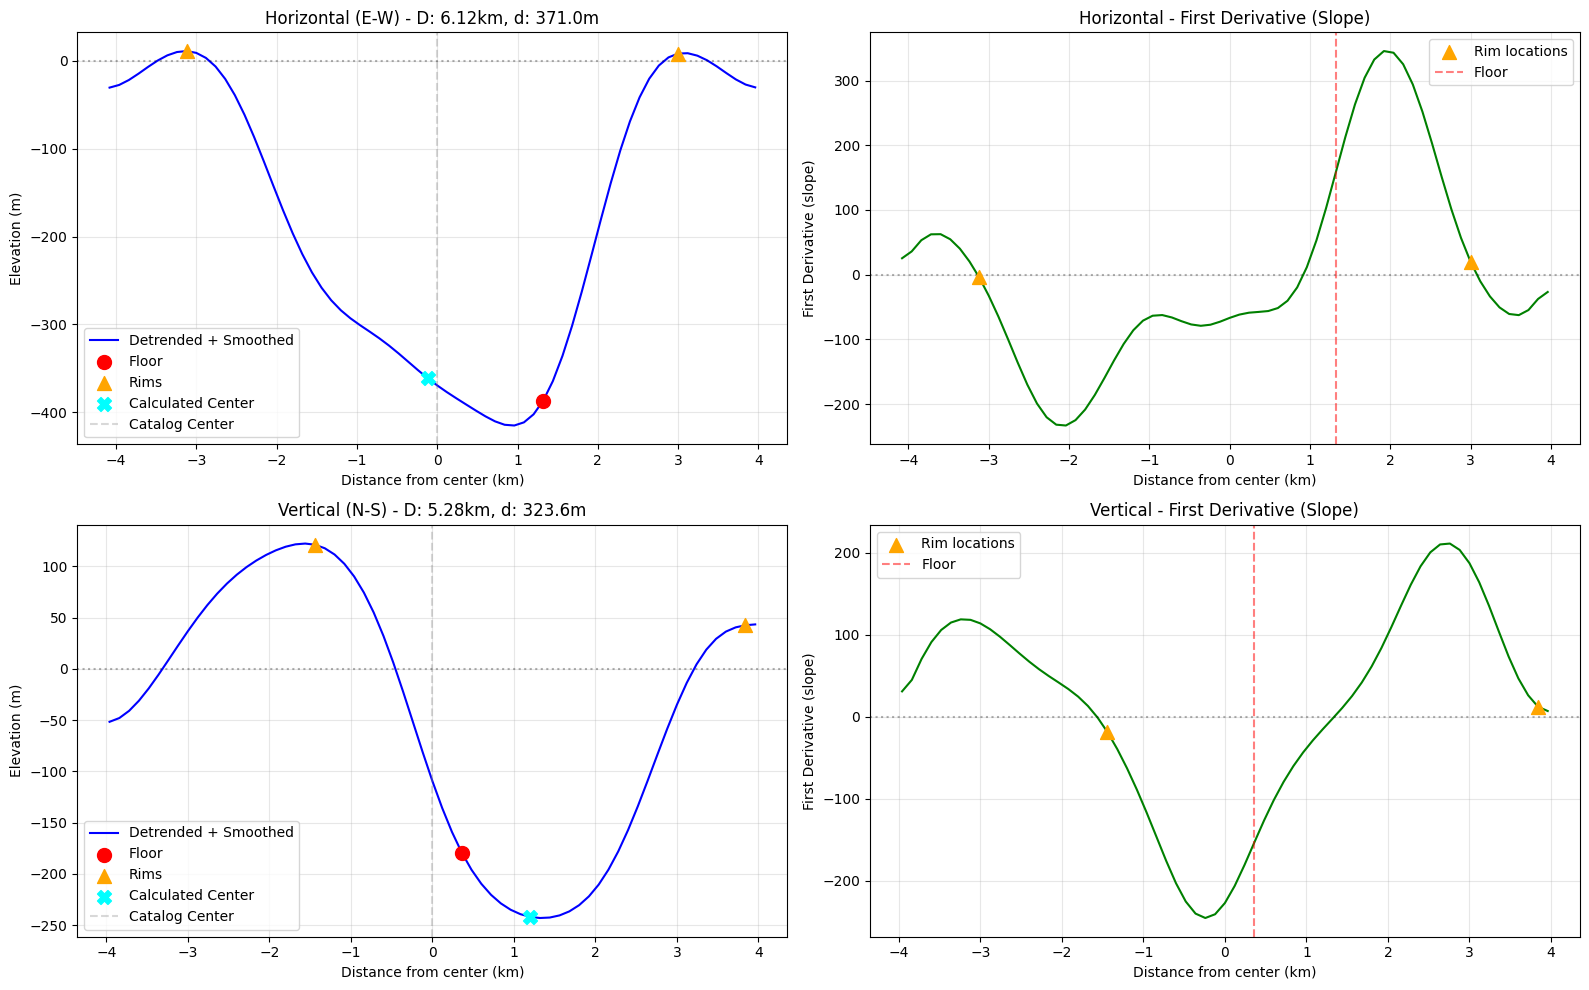

In [9]:
# Import the crater rim finding function
from crater_analysis.analysis import find_crater_rims

try:
    # Find the rims for both profiles (using smoothed data)
    left_rim_idx_h, right_rim_idx_h, left_rim_dist_h, right_rim_dist_h, first_deriv_h = find_crater_rims(
        distance_h, elevation_h_smooth, floor_idx_h, threshold_fraction=0.1
    )

    left_rim_idx_v, right_rim_idx_v, left_rim_dist_v, right_rim_dist_v, first_deriv_v = find_crater_rims(
        distance_v, elevation_v_smooth, floor_idx_v, threshold_fraction=0.1
    )

    # Calculate diameters
    diameter_h = right_rim_dist_h - left_rim_dist_h
    diameter_v = right_rim_dist_v - left_rim_dist_v

    # Calculate depth for Horizontal Profile
    # Center is the midpoint index between the two rims
    center_idx_h = (left_rim_idx_h + right_rim_idx_h) // 2
    center_dist_h = distance_h[center_idx_h]
    center_elev_h = elevation_h_smooth[center_idx_h]
    
    # Average rim elevation
    avg_rim_elev_h = (elevation_h_smooth[left_rim_idx_h] + elevation_h_smooth[right_rim_idx_h]) / 2
    
    # Depth is difference between average rim elevation and center elevation
    depth_h = avg_rim_elev_h - center_elev_h

    # Calculate depth for Vertical Profile
    center_idx_v = (left_rim_idx_v + right_rim_idx_v) // 2
    center_dist_v = distance_v[center_idx_v]
    center_elev_v = elevation_v_smooth[center_idx_v]
    
    avg_rim_elev_v = (elevation_v_smooth[left_rim_idx_v] + elevation_v_smooth[right_rim_idx_v]) / 2
    depth_v = avg_rim_elev_v - center_elev_v

    # Average Depth across both profiles
    avg_depth = (depth_h + depth_v) / 2

    print(f"Horizontal profile:")
    print(f"  Left rim: {left_rim_dist_h:.3f} km, Right rim: {right_rim_dist_h:.3f} km")
    print(f"  Measured diameter: {diameter_h:.3f} km")
    print(f"  Depth: {depth_h:.2f} m (Center elev: {center_elev_h:.2f} m, Avg rim elev: {avg_rim_elev_h:.2f} m)")
    
    print(f"\nVertical profile:")
    print(f"  Left rim: {left_rim_dist_v:.3f} km, Right rim: {right_rim_dist_v:.3f} km")
    print(f"  Measured diameter: {diameter_v:.3f} km")
    print(f"  Depth: {depth_v:.2f} m (Center elev: {center_elev_v:.2f} m, Avg rim elev: {avg_rim_elev_v:.2f} m)")

    print(f"\nCatalog diameter: {crater.get_property('diameter_km'):.3f} km")
    print(f"Measured diameter: {(diameter_h + diameter_v) / 2:.3f} km")
    
    # Uncomment below if catalog has depth column:
    # catalog_depth = crater.get_property('depth_m')
    # print(f"\nCatalog depth: {catalog_depth:.2f} m")
    print(f"\nAverage Measured Depth: {avg_depth:.2f} m")
    print(f"d/D ratio: {avg_depth / ((diameter_h + diameter_v) / 2 * 1000):.4f}")

    # Plot the profiles with floor and rims marked
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Horizontal profile with rims
    axes[0, 0].plot(distance_h, elevation_h_smooth, '-', linewidth=1.5, color='blue', label='Detrended + Smoothed')
    axes[0, 0].scatter(floor_dist_h, floor_elev_h, color='red', s=100, zorder=5, label='Floor')
    axes[0, 0].scatter([left_rim_dist_h, right_rim_dist_h], 
                    [elevation_h_smooth[left_rim_idx_h], elevation_h_smooth[right_rim_idx_h]], 
                    color='orange', s=100, marker='^', zorder=5, label='Rims')
    axes[0, 0].scatter(center_dist_h, center_elev_h, color='cyan', s=100, marker='X', zorder=5, label='Calculated Center')
    
    axes[0, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Catalog Center')
    axes[0, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
    axes[0, 0].set_xlabel('Distance from center (km)')
    axes[0, 0].set_ylabel('Elevation (m)')
    axes[0, 0].set_title(f'Horizontal (E-W) - D: {diameter_h:.2f}km, d: {depth_h:.1f}m')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Horizontal first derivative
    axes[0, 1].plot(distance_h, first_deriv_h, '-', linewidth=1.5, color='green')
    axes[0, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
    axes[0, 1].scatter([left_rim_dist_h, right_rim_dist_h],
                    [first_deriv_h[left_rim_idx_h], first_deriv_h[right_rim_idx_h]],
                    color='orange', s=100, marker='^', zorder=5, label='Rim locations')
    axes[0, 1].axvline(x=floor_dist_h, color='red', linestyle='--', alpha=0.5, label='Floor')
    axes[0, 1].set_xlabel('Distance from center (km)')
    axes[0, 1].set_ylabel('First Derivative (slope)')
    axes[0, 1].set_title('Horizontal - First Derivative (Slope)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Vertical profile with rims
    axes[1, 0].plot(distance_v, elevation_v_smooth, '-', linewidth=1.5, color='blue', label='Detrended + Smoothed')
    axes[1, 0].scatter(floor_dist_v, floor_elev_v, color='red', s=100, zorder=5, label='Floor')
    axes[1, 0].scatter([left_rim_dist_v, right_rim_dist_v],
                    [elevation_v_smooth[left_rim_idx_v], elevation_v_smooth[right_rim_idx_v]],
                    color='orange', s=100, marker='^', zorder=5, label='Rims')
    axes[1, 0].scatter(center_dist_v, center_elev_v, color='cyan', s=100, marker='X', zorder=5, label='Calculated Center')

    axes[1, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Catalog Center')
    axes[1, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
    axes[1, 0].set_xlabel('Distance from center (km)')
    axes[1, 0].set_ylabel('Elevation (m)')
    axes[1, 0].set_title(f'Vertical (N-S) - D: {diameter_v:.2f}km, d: {depth_v:.1f}m')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Vertical first derivative
    axes[1, 1].plot(distance_v, first_deriv_v, '-', linewidth=1.5, color='green')
    axes[1, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
    axes[1, 1].scatter([left_rim_dist_v, right_rim_dist_v],
                    [first_deriv_v[left_rim_idx_v], first_deriv_v[right_rim_idx_v]],
                    color='orange', s=100, marker='^', zorder=5, label='Rim locations')
    axes[1, 1].axvline(x=floor_dist_v, color='red', linestyle='--', alpha=0.5, label='Floor')
    axes[1, 1].set_xlabel('Distance from center (km)')
    axes[1, 1].set_ylabel('First Derivative (slope)')
    axes[1, 1].set_title('Vertical - First Derivative (Slope)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

except ValueError as e:
    print(f"Error finding rims: {e}")

In [ ]:
# Batch analysis: Compare measured depths with catalog depths
from crater_analysis.analysis import (
    detrend_profile_robust, smooth_profile, get_crater_profile,
    find_crater_floor_max_curv, find_crater_rims
)
import numpy as np
import matplotlib.pyplot as plt

# Store results
# Uncomment 'catalog_depth' if your catalog has depth data
results = {
    'measured_depth': [],
    # 'catalog_depth': [],  # Uncomment if catalog has depth column
    'catalog_diameter': [],
    'measured_diameter': [],
    'crater_idx': [],
    'error_craters': []  # Track craters that failed
}

# Processing parameters
sigma = 3
detrend_fraction = 0.2
profile_factor = 1.5

print("Processing craters...")
for i, crater in enumerate(crater_objects):
    try:
        # Extract profiles
        distance_h, elevation_h, _ = get_crater_profile(
            crater.dem_data, crater.metadata,
            crater.global_coords['lon'], crater.global_coords['lat'],
            crater_diam_km=crater.get_property('diameter_km') * profile_factor,
            angle=0
        )
        distance_v, elevation_v, _ = get_crater_profile(
            crater.dem_data, crater.metadata,
            crater.global_coords['lon'], crater.global_coords['lat'],
            crater_diam_km=crater.get_property('diameter_km') * profile_factor,
            angle=90
        )
        
        # Detrend and smooth
        elevation_h_detrended, _, _ = detrend_profile_robust(distance_h, elevation_h, fraction=detrend_fraction)
        elevation_v_detrended, _, _ = detrend_profile_robust(distance_v, elevation_v, fraction=detrend_fraction)
        elevation_h_smooth = smooth_profile(elevation_h_detrended, sigma=sigma)
        elevation_v_smooth = smooth_profile(elevation_v_detrended, sigma=sigma)
        
        # Find floor
        floor_idx_h, _, _, _ = find_crater_floor_max_curv(distance_h, elevation_h_smooth)
        floor_idx_v, _, _, _ = find_crater_floor_max_curv(distance_v, elevation_v_smooth)
        
        # Find rims
        left_rim_idx_h, right_rim_idx_h, left_rim_dist_h, right_rim_dist_h, _ = find_crater_rims(
            distance_h, elevation_h_smooth, floor_idx_h, threshold_fraction=0.1
        )
        left_rim_idx_v, right_rim_idx_v, left_rim_dist_v, right_rim_dist_v, _ = find_crater_rims(
            distance_v, elevation_v_smooth, floor_idx_v, threshold_fraction=0.1
        )
        
        # Calculate depths
        center_idx_h = (left_rim_idx_h + right_rim_idx_h) // 2
        avg_rim_elev_h = (elevation_h_smooth[left_rim_idx_h] + elevation_h_smooth[right_rim_idx_h]) / 2
        depth_h = avg_rim_elev_h - elevation_h_smooth[center_idx_h]
        
        center_idx_v = (left_rim_idx_v + right_rim_idx_v) // 2
        avg_rim_elev_v = (elevation_v_smooth[left_rim_idx_v] + elevation_v_smooth[right_rim_idx_v]) / 2
        depth_v = avg_rim_elev_v - elevation_v_smooth[center_idx_v]
        
        avg_depth = (depth_h + depth_v) / 2
        
        # Calculate diameters
        diameter_h = right_rim_dist_h - left_rim_dist_h
        diameter_v = right_rim_dist_v - left_rim_dist_v
        # Store results (filter by reasonable d/D ratio)
        if 0.025 < avg_depth/(avg_diameter * 1000) < 0.25:
            results['measured_depth'].append(avg_depth)
            # results['catalog_depth'].append(crater.get_property('depth_m'))  # Uncomment if catalog has depth
        if 0.025 < avg_depth/(avg_diameter * 1000) < 0.25:
            results['measured_depth'].append(avg_depth)
            results['catalog_diameter'].append(crater.get_property('diameter_km'))
            results['measured_diameter'].append(avg_diameter)
            results['crater_idx'].append(i)
        
    except ValueError as e:
        results['error_craters'].append((i, str(e)))
        continue
    
    if (i + 1) % 50 == 0:
print(f"\nSuccessfully processed {len(results['measured_depth'])} craters")
# print(f"With catalog depths: {len(results['catalog_depth'])} craters")  # Uncomment if using catalog depths
print(f"\nSuccessfully processed {len(results['catalog_depth'])} craters")
print(f"\nSuccessfully processed {len(results['measured_depth'])} craters")
measured_depths = np.array(results['measured_depth'])
# catalog_depths = np.array(results['catalog_depth'])  # Uncomment if catalog has depth
catalog_depths = np.array(results['catalog_depth'])
measured_depths = np.array(results['measured_depth'])

catalog_diameters = np.array(results['catalog_diameter'])measured_diameters = np.array(results['measured_diameter'])

Processing craters...
  Processed 50/3530 craters...
  Processed 100/3530 craters...
  Processed 250/3530 craters...
  Processed 300/3530 craters...
  Processed 400/3530 craters...
  Processed 450/3530 craters...
  Processed 650/3530 craters...
  Processed 700/3530 craters...
  Processed 750/3530 craters...
  Processed 800/3530 craters...
  Processed 850/3530 craters...
  Processed 900/3530 craters...
  Processed 950/3530 craters...
  Processed 1100/3530 craters...
  Processed 1150/3530 craters...
  Processed 1250/3530 craters...
  Processed 1300/3530 craters...
  Processed 1350/3530 craters...
  Processed 1400/3530 craters...
  Processed 1450/3530 craters...
  Processed 1550/3530 craters...
  Processed 1600/3530 craters...
  Processed 1650/3530 craters...
  Processed 1700/3530 craters...
  Processed 1750/3530 craters...
  Processed 1800/3530 craters...
  Processed 1850/3530 craters...


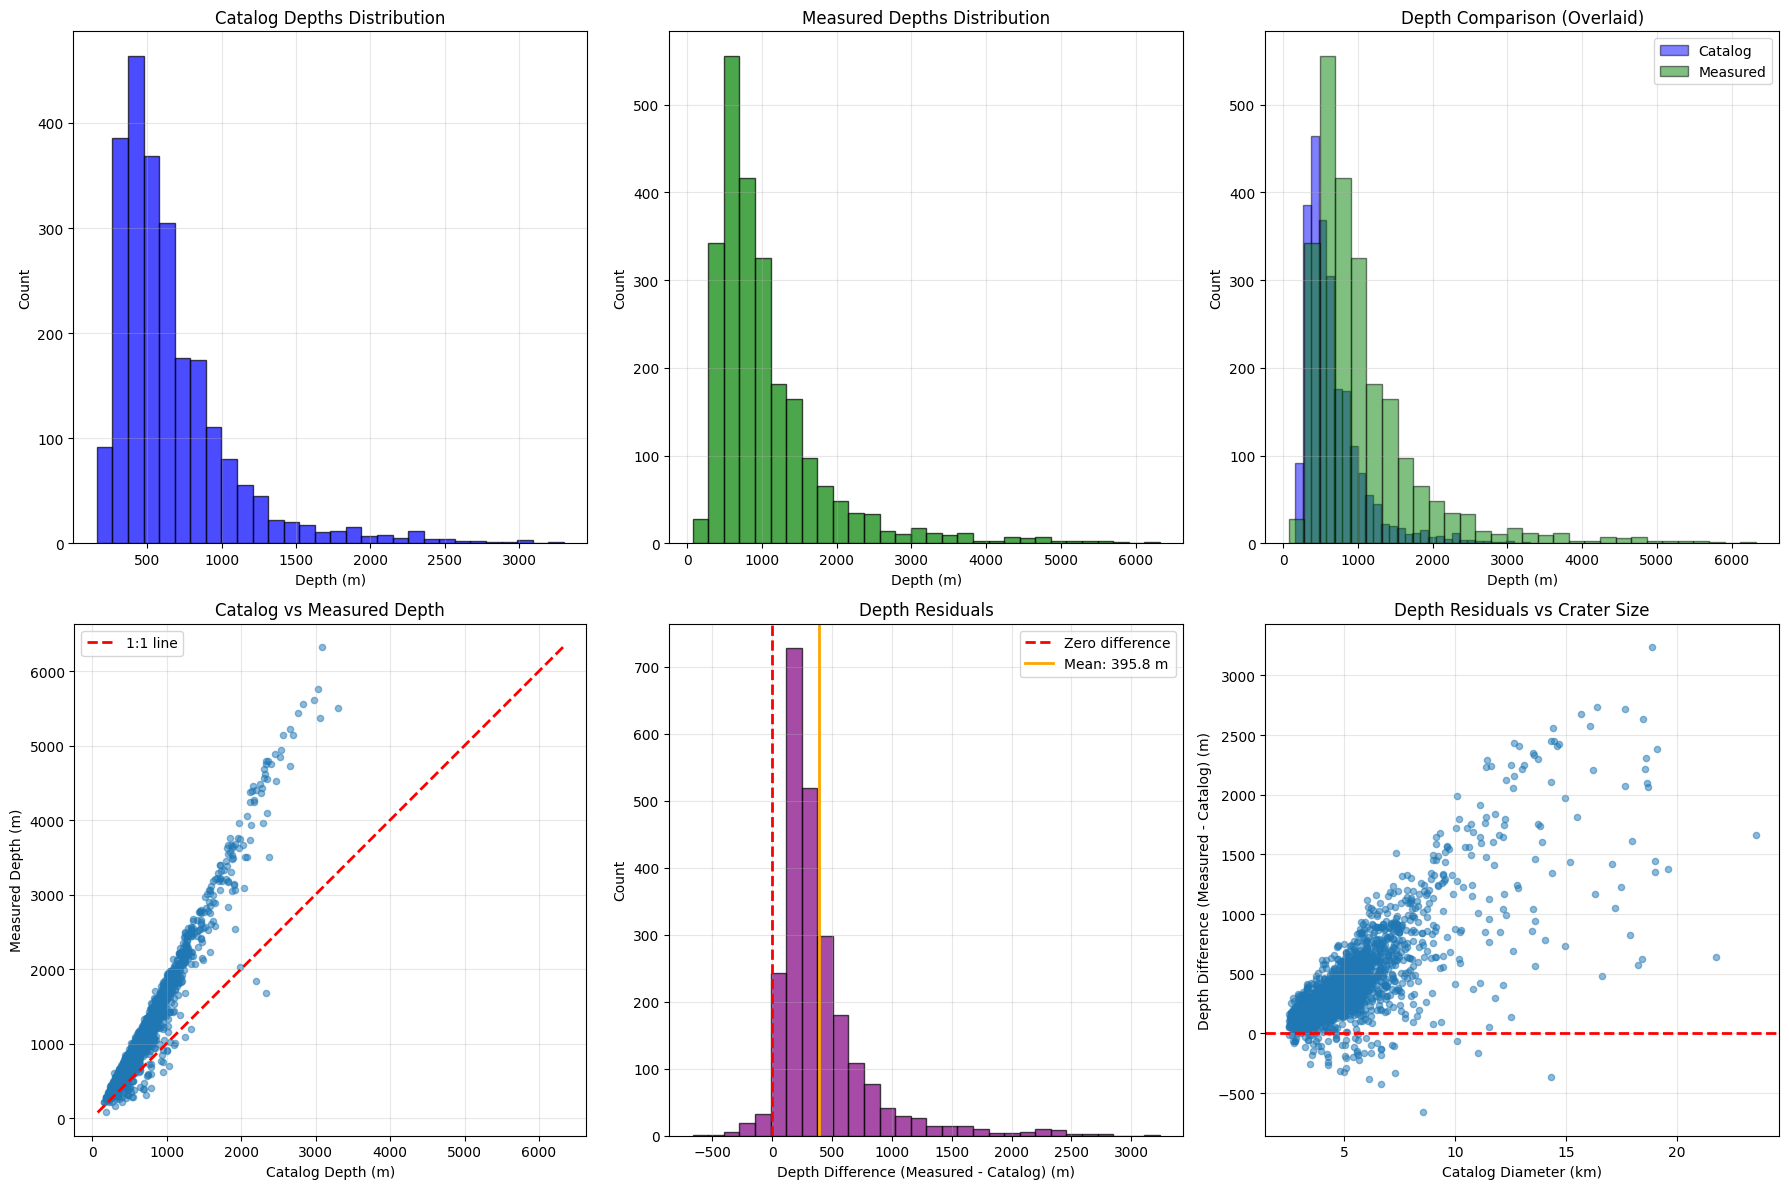


SUMMARY STATISTICS

Catalog Depths:
  Mean: 658.5 m
  Median: 547.7 m
  Std Dev: 402.7 m
  Range: 160.0 - 3301.2 m

Measured Depths:
  Mean: 1054.3 m
  Median: 828.0 m
  Std Dev: 775.2 m
  Range: 74.5 - 6322.2 m

Depth Differences (Measured - Catalog):
  Mean: 395.8 m
  Median: 283.9 m
  Std Dev: 392.8 m
  Range: -662.7 - 3237.5 m

Correlation (Catalog vs Measured): 0.975
Percentage where Measured > Catalog: 97.3%


In [ ]:
# Create visualizations for measured depths
# Uncomment catalog comparison code if your catalog has depth data
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram of measured depths
axes[0].hist(measured_depths, bins=30, alpha=0.7, color='green', edgecolor='black', label='Measured')
# axes[0].hist(catalog_depths, bins=30, alpha=0.5, color='blue', edgecolor='black', label='Catalog')  # Uncomment for comparison
axes[0].set_xlabel('Depth (m)')
axes[0].set_ylabel('Count')
axes[0].set_title('Depth Distribution')
# axes[0].legend()  # Uncomment if showing both
axes[0].grid(True, alpha=0.3)

# 2. Histogram of measured diameters
axes[1].hist(measured_diameters, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[1].set_xlabel('Diameter (km)')
axes[1].set_ylabel('Count')
axes[1].set_title('Measured Diameters Distribution')
axes[1].grid(True, alpha=0.3)

# 3. Depth vs Diameter scatter (measured only, or comparison)
d_D_ratio = measured_depths / (measured_diameters * 1000)
axes[2].scatter(measured_diameters, measured_depths, alpha=0.5, s=20, c=d_D_ratio, cmap='viridis', label='Measured')
# axes[2].scatter(catalog_diameters, catalog_depths, alpha=0.3, s=20, color='red', label='Catalog')  # Uncomment for comparison
axes[2].set_xlabel('Diameter (km)')
axes[2].set_ylabel('Depth (m)')
axes[2].set_title('Depth vs Diameter')
# axes[2].legend()  # Uncomment if showing both
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# CATALOG COMPARISON (Uncomment if catalog has depth data)
# ============================================
# # Measured vs Catalog scatter plot
# fig2, ax = plt.subplots(figsize=(8, 8))
# ax.scatter(catalog_depths, measured_depths, alpha=0.5, s=20)
# max_depth = max(catalog_depths.max(), measured_depths.max())
# ax.plot([0, max_depth], [0, max_depth], 'r--', label='1:1 line')
# ax.set_xlabel('Catalog Depth (m)')
# ax.set_ylabel('Measured Depth (m)')
# ax.set_title('Measured vs Catalog Depth Comparison')
# ax.legend()
# ax.grid(True, alpha=0.3)
# ax.set_aspect('equal')
# plt.tight_layout()
# plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print(f"\nMeasured Depths:")
print(f"  Mean: {np.mean(measured_depths):.1f} m")
print(f"  Median: {np.median(measured_depths):.1f} m")
print(f"  Std Dev: {np.std(measured_depths):.1f} m")
print(f"  Range: {np.min(measured_depths):.1f} - {np.max(measured_depths):.1f} m")

# Uncomment for catalog comparison:
# print(f"\nCatalog Depths:")
# print(f"  Mean: {np.mean(catalog_depths):.1f} m")
# print(f"  Median: {np.median(catalog_depths):.1f} m")
# print(f"  Std Dev: {np.std(catalog_depths):.1f} m")
# print(f"  Range: {np.min(catalog_depths):.1f} - {np.max(catalog_depths):.1f} m")

print(f"\nMeasured Diameters:")
print(f"  Mean: {np.mean(measured_diameters):.2f} km")
print(f"  Median: {np.median(measured_diameters):.2f} km")
print(f"  Std Dev: {np.std(measured_diameters):.2f} km")
print(f"  Range: {np.min(measured_diameters):.2f} - {np.max(measured_diameters):.2f} km")

print(f"\nd/D Ratio (Measured):")
print(f"  Mean: {np.mean(d_D_ratio):.4f}")
print(f"  Median: {np.median(d_D_ratio):.4f}")
print(f"  Std Dev: {np.std(d_D_ratio):.4f}")
print(f"  Range: {np.min(d_D_ratio):.4f} - {np.max(d_D_ratio):.4f}")

Successfully processed: 2404 craters
Failed to process: 1126 craters
Include failed in catalog bins: True


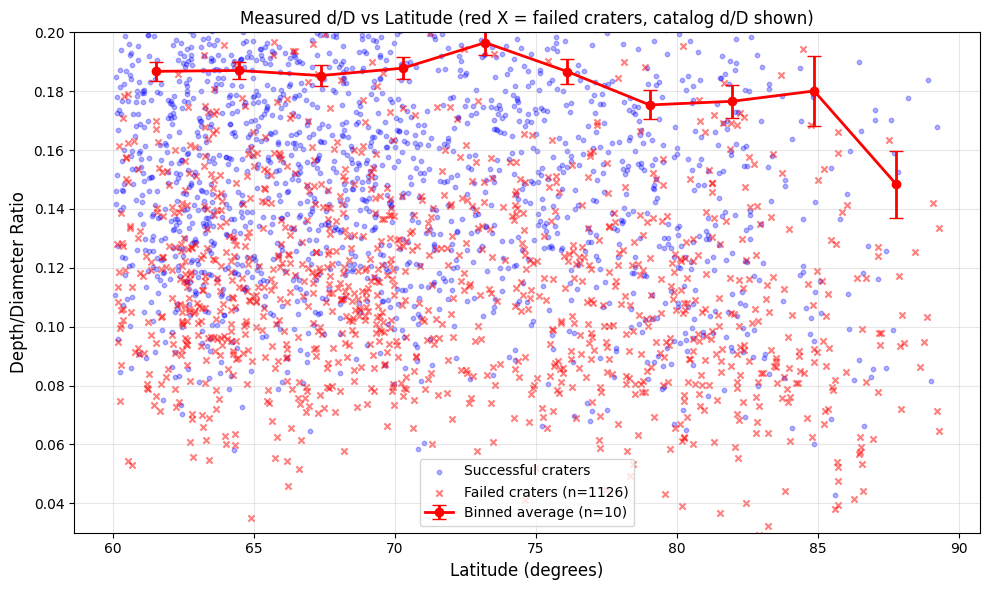

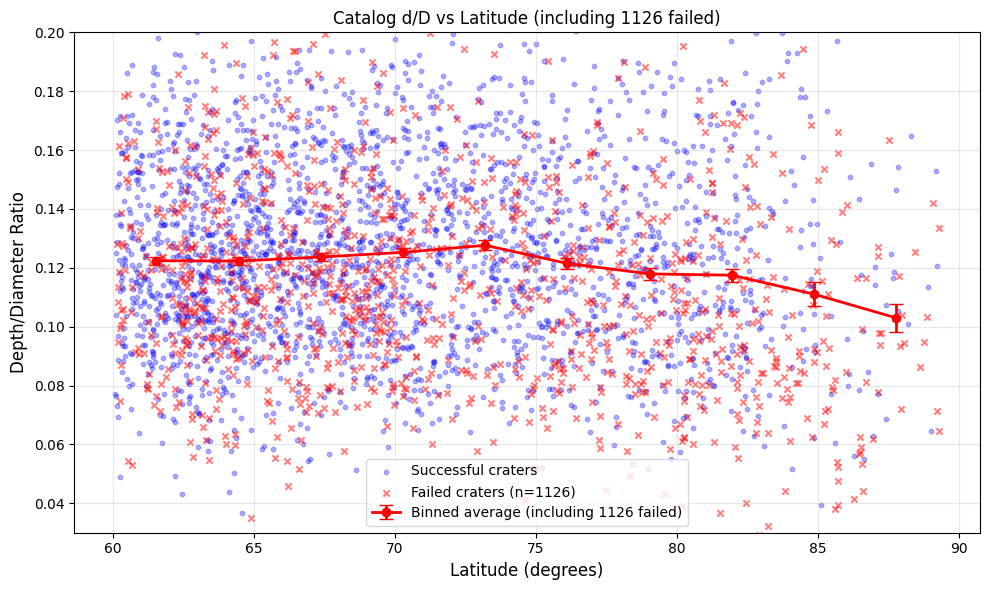

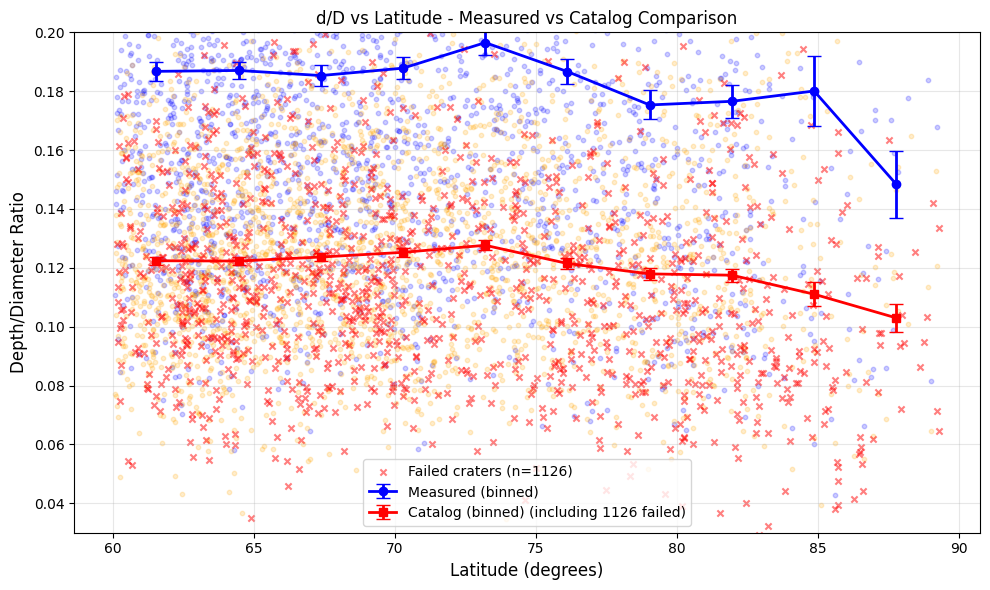

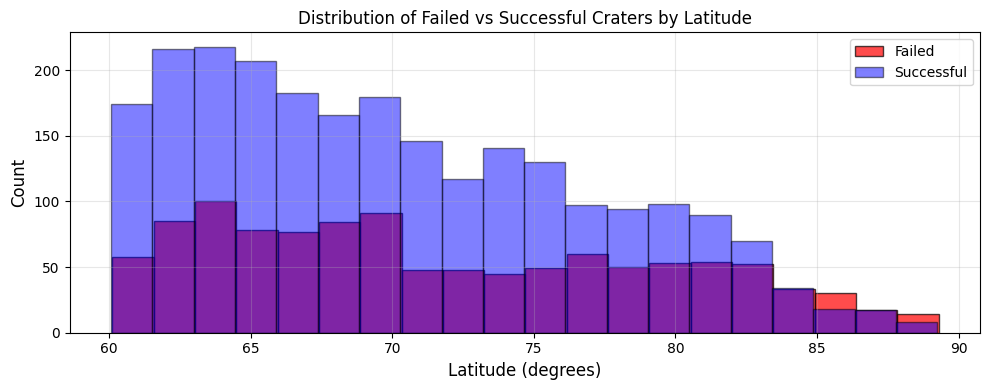

In [ ]:
# Plot depth/diameter ratio vs latitude
# Uncomment catalog comparison code if your catalog has depth data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get latitudes for successfully processed craters
latitudes = np.array([crater_objects[i].global_coords['lat'] for i in results['crater_idx']])

# Calculate depth/diameter ratio (convert diameter from km to m for consistent units)
# depth is in meters, diameter is in km, so multiply diameter by 1000
d_D_ratio_measured = measured_depths / (measured_diameters * 1000)
# d_D_ratio_catalog = catalog_depths / (catalog_diameters * 1000)  # Uncomment if catalog has depth

# Get data for FAILED craters
failed_indices = [idx for idx, _ in results['error_craters']]
failed_latitudes = np.array([crater_objects[i].global_coords['lat'] for i in failed_indices]) if failed_indices else np.array([])
# failed_catalog_depths = np.array([crater_objects[i].get_property('depth_m') for i in failed_indices]) if failed_indices else np.array([])  # Uncomment if catalog has depth

# Use absolute latitude for plotting
abs_latitudes = np.abs(latitudes)
abs_failed_latitudes = np.abs(failed_latitudes) if len(failed_latitudes) > 0 else np.array([])

# Create DataFrame for binning
df = pd.DataFrame({
    'lat': abs_latitudes,
    'd_D_measured': d_D_ratio_measured,
    # 'd_D_catalog': d_D_ratio_catalog,  # Uncomment if catalog has depth
})

# Binning parameters
n_bins = 10
lat_bins = np.linspace(df['lat'].min(), df['lat'].max(), n_bins + 1)
bin_centers = (lat_bins[:-1] + lat_bins[1:]) / 2

# Calculate binned statistics for measured data
measured_means = []
measured_sems = []
# catalog_means = []  # Uncomment if catalog has depth
# catalog_sems = []   # Uncomment if catalog has depth
for i in range(len(lat_bins) - 1):
    mask = (df['lat'] >= lat_bins[i]) & (df['lat'] < lat_bins[i+1])
    bin_data = df[mask]['d_D_measured']
    if len(bin_data) > 0:
        measured_means.append(bin_data.mean())
        measured_sems.append(bin_data.std() / np.sqrt(len(bin_data)))
    else:
        measured_means.append(np.nan)
        measured_sems.append(np.nan)
    
    # Uncomment for catalog comparison:
    # bin_data_cat = df[mask]['d_D_catalog']
    # if len(bin_data_cat) > 0:
    #     catalog_means.append(bin_data_cat.mean())
    #     catalog_sems.append(bin_data_cat.std() / np.sqrt(len(bin_data_cat)))
    # else:
    #     catalog_means.append(np.nan)
    #     catalog_sems.append(np.nan)

measured_means = np.array(measured_means)
measured_sems = np.array(measured_sems)
# catalog_means = np.array(catalog_means)  # Uncomment if catalog has depth
# catalog_sems = np.array(catalog_sems)    # Uncomment if catalog has depth

print(f"Successfully processed: {len(abs_latitudes)} craters")
print(f"Failed to process: {len(abs_failed_latitudes)} craters")

# Plot: Measured d/D vs Latitude
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.scatter(abs_latitudes, d_D_ratio_measured, alpha=0.3, s=10, color='blue', label='Successful craters')
if len(abs_failed_latitudes) > 0:
    ax1.scatter(abs_failed_latitudes, np.full_like(abs_failed_latitudes, 0.1), 
                alpha=0.3, s=20, color='red', marker='x', label=f'Failed craters (n={len(failed_indices)})')
ax1.errorbar(bin_centers, measured_means, yerr=measured_sems, 
             color='red', linewidth=2, marker='o', markersize=6,
             capsize=5, label=f'Binned average (n={n_bins})')
ax1.set_xlabel('Latitude (degrees)', fontsize=12)
ax1.set_ylabel('Depth/Diameter Ratio', fontsize=12)
ax1.set_title('Measured d/D vs Latitude (Robbins Catalog)')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim(0.03, 0.2)
plt.tight_layout()
plt.show()

# ============================================
# CATALOG COMPARISON PLOT (Uncomment if catalog has depth data)
# ============================================
# fig2, ax2 = plt.subplots(figsize=(10, 6))
# ax2.scatter(abs_latitudes, d_D_ratio_catalog, alpha=0.3, s=10, color='blue', label='Catalog d/D')
# ax2.errorbar(bin_centers, catalog_means, yerr=catalog_sems, 
#              color='blue', linewidth=2, marker='s', markersize=6,
#              capsize=5, label=f'Catalog binned avg')
# ax2.errorbar(bin_centers, measured_means, yerr=measured_sems, 
#              color='red', linewidth=2, marker='o', markersize=6,
#              capsize=5, label=f'Measured binned avg')
# ax2.set_xlabel('Latitude (degrees)', fontsize=12)
# ax2.set_ylabel('Depth/Diameter Ratio', fontsize=12)
# ax2.set_title('d/D vs Latitude: Measured vs Catalog Comparison')
# ax2.grid(True, alpha=0.3)
# ax2.legend()
# ax2.set_ylim(0.03, 0.2)
# plt.tight_layout()
# plt.show()

# Show distribution of failed craters by latitude
if len(failed_indices) > 0:
    fig3, ax3 = plt.subplots(figsize=(10, 4))
    ax3.hist(abs_failed_latitudes, bins=20, alpha=0.7, color='red', edgecolor='black', label='Failed')
    ax3.hist(abs_latitudes, bins=20, alpha=0.5, color='blue', edgecolor='black', label='Successful')
    ax3.set_xlabel('Latitude (degrees)', fontsize=12)
    ax3.set_ylabel('Count', fontsize=12)
    ax3.set_title('Distribution of Failed vs Successful Craters by Latitude')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()